In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Cell 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.math import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.layers import InputLayer, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
tf.random.set_seed(3)

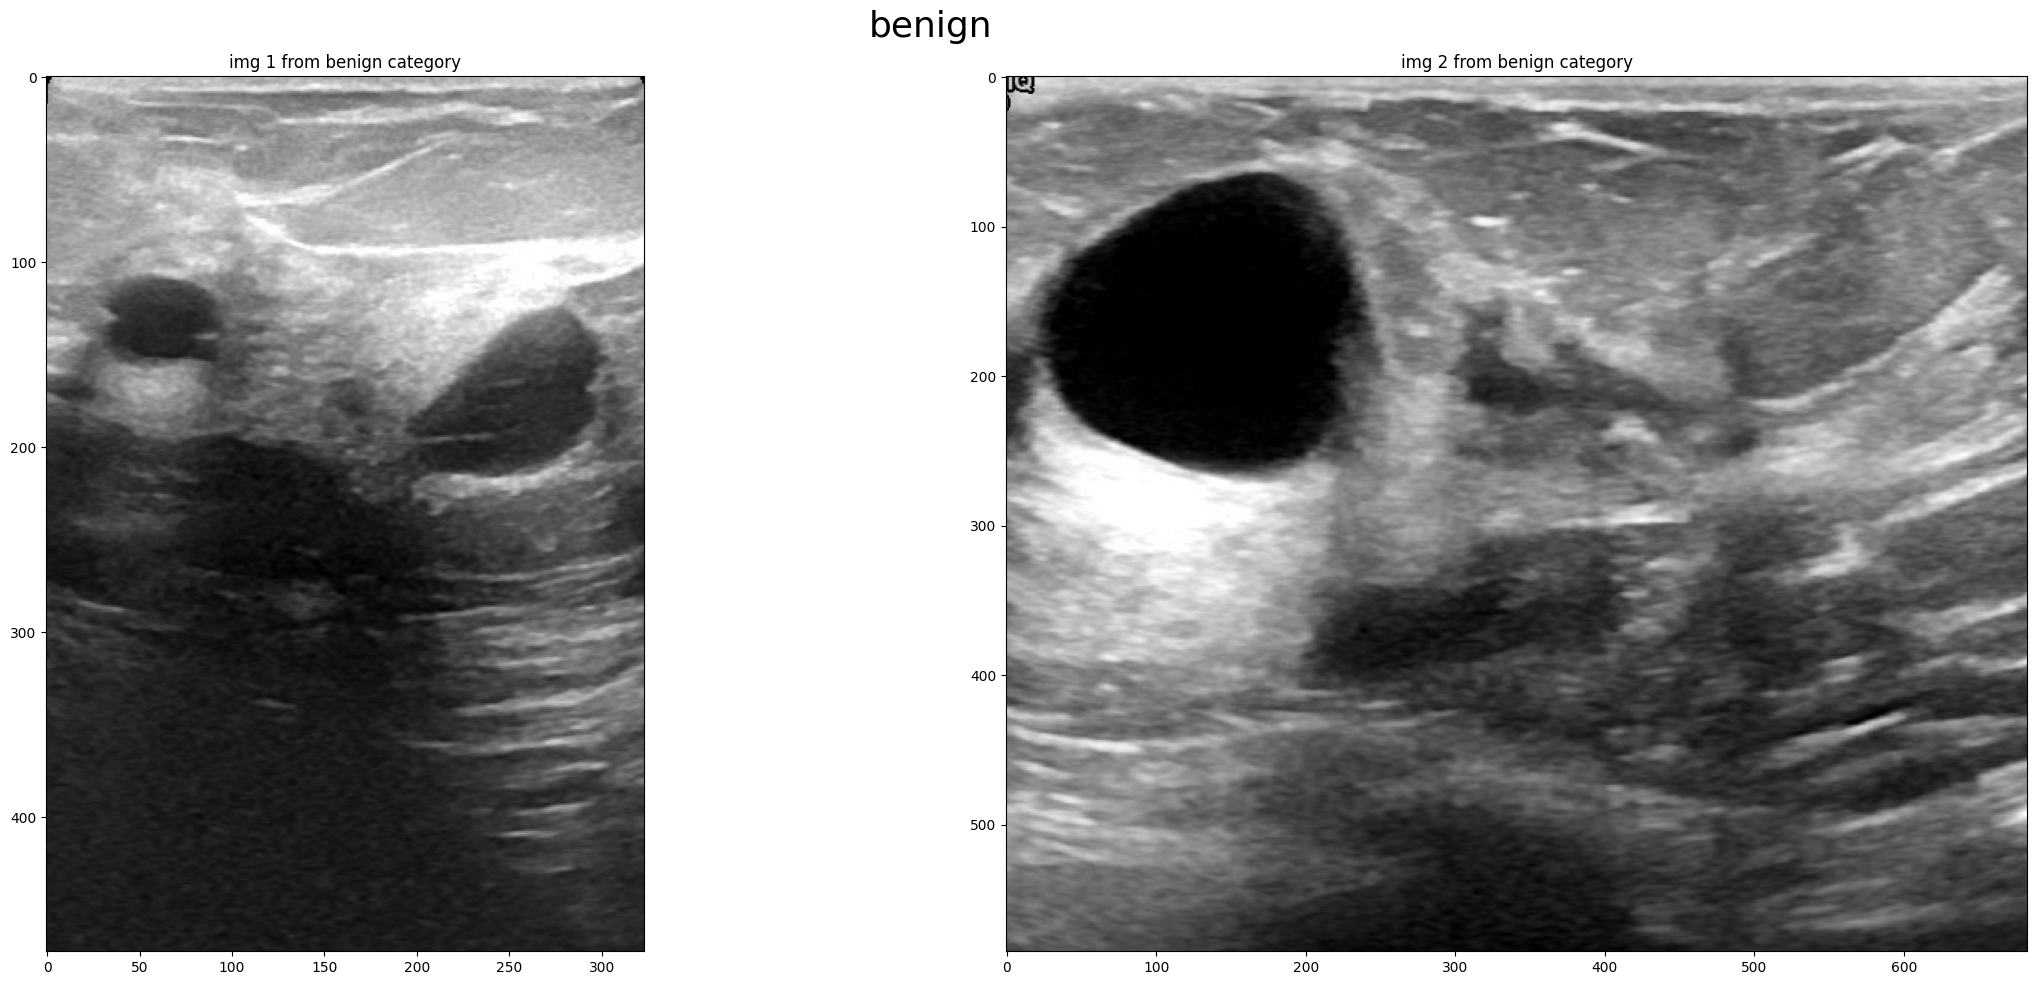

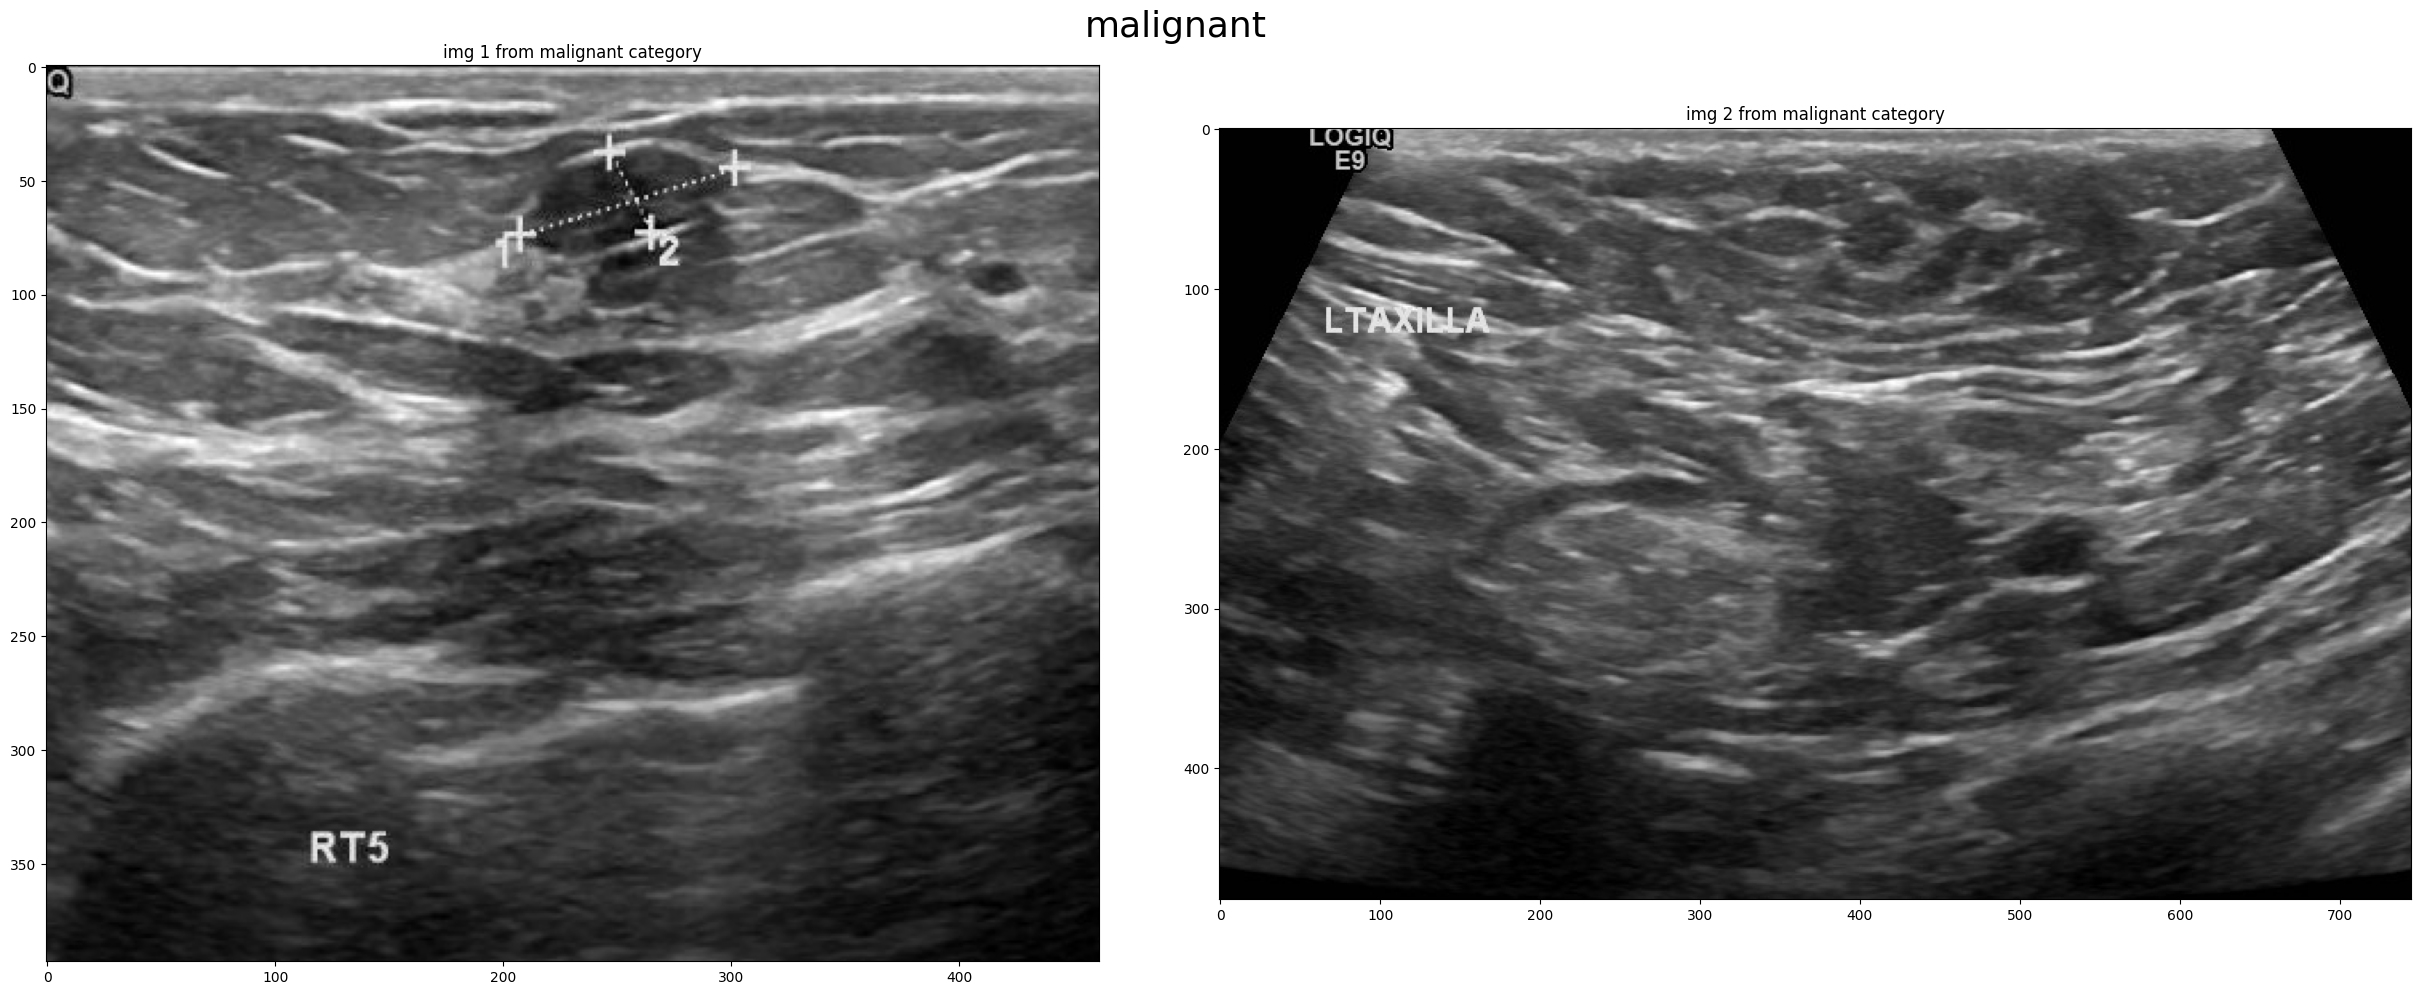

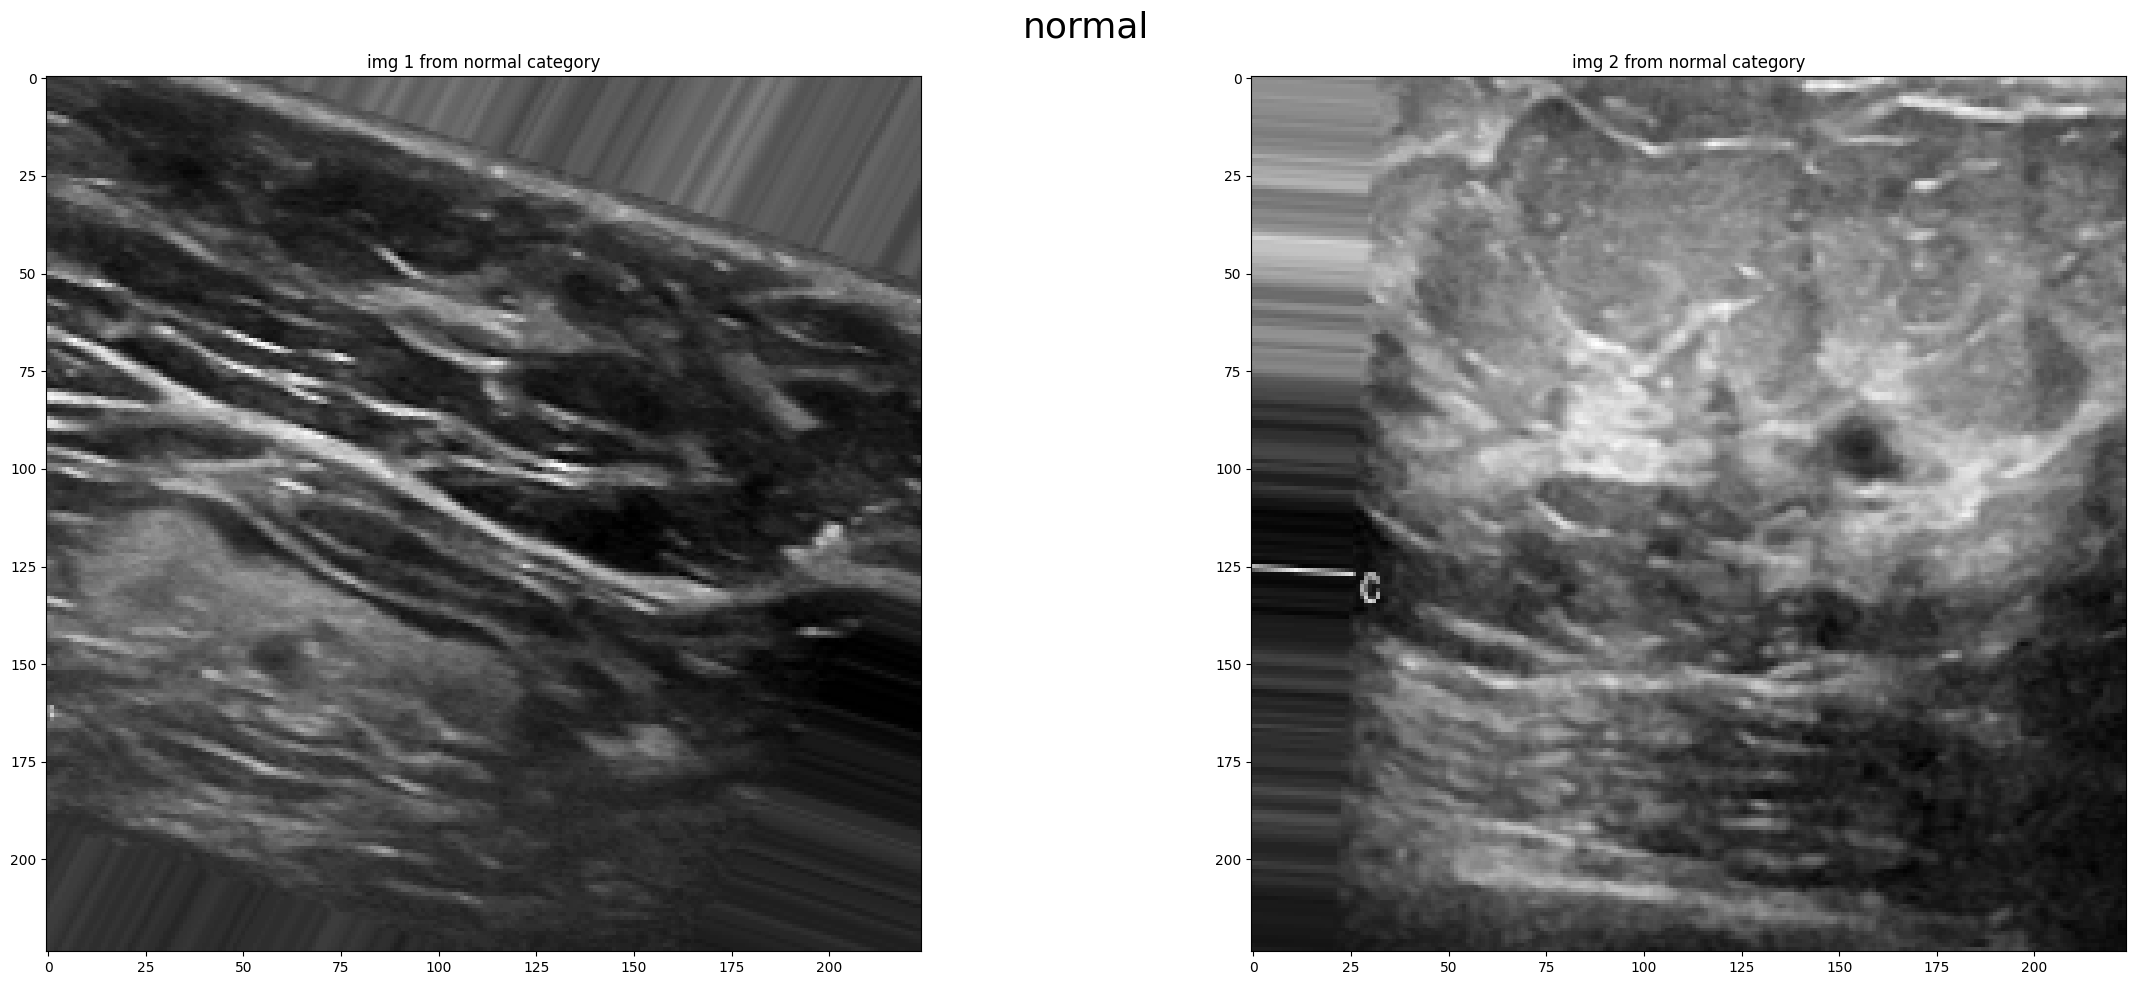

In [ ]:
# Cell 2: Load and display some images from the dataset
folder_name = '/content/drive/MyDrive/Colab_Notebooks/breast_dataset1000'
files_names = ['benign', 'malignant', 'normal']

for file in files_names:
    path = os.path.join(folder_name, file)
    x = 0
    fig, axes = plt.subplots(1, 2, figsize=(25, 10))
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        axes[x].imshow(img_array, cmap='gray')
        axes[x].set_title(f"img {x+1} from {file} category")
        x += 1
        if x == 2:
            break

    plt.suptitle(file, fontsize=26)
    plt.tight_layout()
    plt.show()

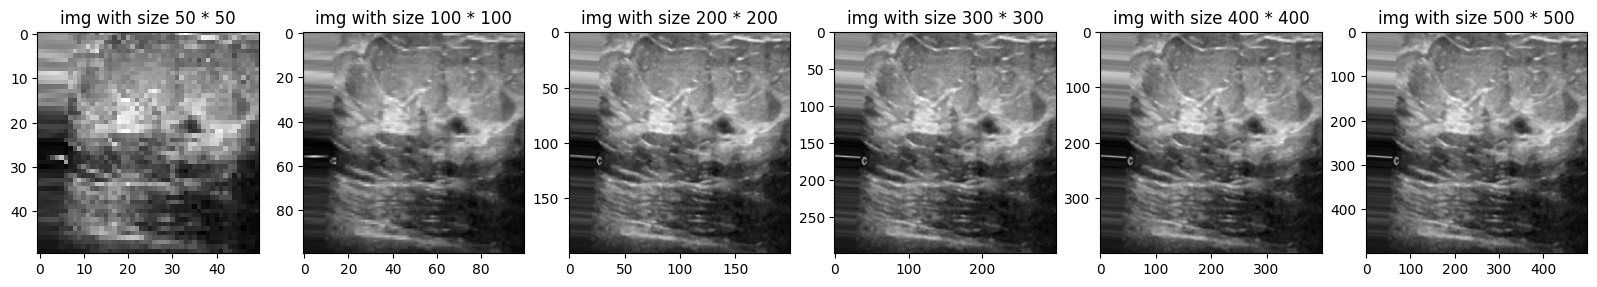

In [ ]:
# Cell 3: Resize images and display examples with different sizes
img_sz = [50, 100, 200, 300, 400, 500]
plt.figure(figsize=(20, 5))

for i, sz in enumerate(img_sz):
    new_array = cv2.resize(img_array, (sz, sz))
    plt.subplot(1, len(img_sz), i+1)
    plt.imshow(new_array, cmap='gray')
    plt.title(f"img with size {sz} * {sz}")

plt.show()

In [ ]:
# Cell 4: Create training data
img_sz = 300
training_data = []

def create_training_data():
    for file in files_names:
        path = os.path.join(folder_name, file)
        class_num = files_names.index(file)
        print(file, class_num)

        for img in tqdm(os.listdir(path)):
            img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
            new_array = cv2.resize(img_array, (img_sz, img_sz))  # Include resizing
            training_data.append([new_array, class_num])

create_training_data()

benign 0


100%|██████████| 1000/1000 [00:05<00:00, 170.19it/s]


malignant 1


100%|██████████| 1000/1000 [00:06<00:00, 156.36it/s]


normal 2


100%|██████████| 1127/1127 [00:06<00:00, 177.61it/s]


In [ ]:
# Cell 5: Display class numbers for some images
for i in range(5):
    print("Class number for image", i+1, ":", training_data[i][1])

for i in range(-1, -6, -1):
    print("Class number for image", len(training_data) + i + 1, ":", training_data[i][1])

Class number for image 1 : 0
Class number for image 2 : 0
Class number for image 3 : 0
Class number for image 4 : 0
Class number for image 5 : 0
Class number for image 3127 : 2
Class number for image 3126 : 2
Class number for image 3125 : 2
Class number for image 3124 : 2
Class number for image 3123 : 2


In [ ]:
# Cell 6: Shuffle the data and display the first 30 class labels after shuffling
random.shuffle(training_data)

for i in range(30):
    print(f"Sample {i+1}:")
    print("Class number:", training_data[i][1],"\n")

Sample 1:
Class number: 1 

Sample 2:
Class number: 2 

Sample 3:
Class number: 0 

Sample 4:
Class number: 1 

Sample 5:
Class number: 1 

Sample 6:
Class number: 1 

Sample 7:
Class number: 1 

Sample 8:
Class number: 1 

Sample 9:
Class number: 1 

Sample 10:
Class number: 0 

Sample 11:
Class number: 1 

Sample 12:
Class number: 1 

Sample 13:
Class number: 0 

Sample 14:
Class number: 0 

Sample 15:
Class number: 0 

Sample 16:
Class number: 0 

Sample 17:
Class number: 2 

Sample 18:
Class number: 0 

Sample 19:
Class number: 2 

Sample 20:
Class number: 1 

Sample 21:
Class number: 2 

Sample 22:
Class number: 0 

Sample 23:
Class number: 1 

Sample 24:
Class number: 1 

Sample 25:
Class number: 2 

Sample 26:
Class number: 2 

Sample 27:
Class number: 0 

Sample 28:
Class number: 2 

Sample 29:
Class number: 2 

Sample 30:
Class number: 1 



In [ ]:
# Cell 7: Prepare feature and label arrays
X = []
y = []

for feature, label in training_data:
    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

(3127, 300, 300)
(3127,)


In [ ]:
# Cell 8: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(np.unique(y_train))
print(np.unique(y_test))

(2501, 300, 300)
(2501,)
(626, 300, 300)
(626,)
[0 1 2]
[0 1 2]


[[0.20392157 0.4627451  0.41176471 ... 0.72156863 0.70196078 0.67058824]
 [0.23921569 0.46666667 0.38039216 ... 0.69019608 0.67058824 0.64313725]
 [0.23529412 0.47058824 0.38823529 ... 0.67058824 0.65882353 0.64313725]
 ...
 [0.09411765 0.09803922 0.10196078 ... 0.08627451 0.08627451 0.09019608]
 [0.10588235 0.10588235 0.10588235 ... 0.09019608 0.09411765 0.09803922]
 [0.11764706 0.11764706 0.10980392 ... 0.09411765 0.09411765 0.09019608]]


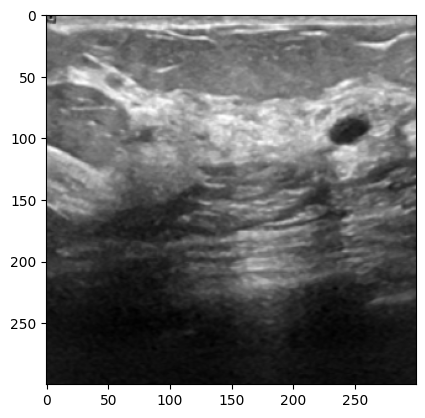

In [ ]:
# Cell 9: Scale the images
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train[0])
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [ ]:
def create_mlp_model():
    model = Sequential([
        Flatten(input_shape=(img_sz, img_sz)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_vgg16_model():
    base_model = VGG16(include_top=False, input_shape=(img_sz, img_sz, 3))
    base_model.trainable = False
    model = Sequential([
        InputLayer(input_shape=(img_sz, img_sz, 1)),
        Conv2D(3, (3, 3), padding='same'),  # Convert grayscale to RGB
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_resnet50_model():
    base_model = ResNet50(include_top=False, input_shape=(img_sz, img_sz, 3))
    base_model.trainable = False
    model = Sequential([
        InputLayer(input_shape=(img_sz, img_sz, 1)),
        Conv2D(3, (3, 3), padding='same'),  # Convert grayscale to RGB
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

mlp_model = create_mlp_model()
vgg16_model = create_vgg16_model()
resnet50_model = create_resnet50_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# Cell 11: Train the models
history_mlp = mlp_model.fit(X_train, y_train, epochs=10, validation_split=0.1)
mlp_model.save('/content/drive/MyDrive/Colab_Notebooks/final_mlp_model.keras')

history_vgg16 = vgg16_model.fit(np.expand_dims(X_train, axis=-1), y_train, epochs=10, validation_split=0.1)
vgg16_model.save('/content/drive/MyDrive/Colab_Notebooks/final_vgg16_model.keras')

history_resnet50 = resnet50_model.fit(np.expand_dims(X_train, axis=-1), y_train, epochs=10, validation_split=0.1)
resnet50_model.save('/content/drive/MyDrive/Colab_Notebooks/final_resnet50_model.keras')

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.4524 - loss: 1.2837 - val_accuracy: 0.5498 - val_loss: 1.1041
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5813 - loss: 0.9300 - val_accuracy: 0.6016 - val_loss: 0.9169
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6787 - loss: 0.8069 - val_accuracy: 0.6454 - val_loss: 0.9342
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7133 - loss: 0.6927 - val_accuracy: 0.7888 - val_loss: 0.5687
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7604 - loss: 0.5985 - val_accuracy: 0.8048 - val_loss: 0.5030
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7951 - loss: 0.5189 - val_accuracy: 0.7968 - val_loss: 0.5364
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8378 - loss: 0.4306 - val_accuracy: 0.7888 - val_loss: 0.5183
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8711 - loss: 0.3632 - val_accuracy: 0.8287 - v

In [ ]:
# RECOVERY CELL — run this if kernel restarted, then skip to Cell 12
import numpy as np, cv2, os, random
from sklearn.model_selection import train_test_split
import tensorflow as tf

img_sz = 300
folder_name = '/content/drive/MyDrive/Colab_Notebooks/breast_dataset1000'
files_names = ['benign', 'malignant', 'normal']

training_data = []
for file in files_names:
    path = os.path.join(folder_name, file)
    for img in os.listdir(path):
        arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        if arr is not None:
            training_data.append([cv2.resize(arr, (img_sz, img_sz)), files_names.index(file)])

random.shuffle(training_data)
X = np.array([i[0] for i in training_data]) / 255.0
y = np.array([i[1] for i in training_data])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlp_model      = tf.keras.models.load_model('/content/drive/MyDrive/Colab_Notebooks/final_mlp_model.keras')
vgg16_model    = tf.keras.models.load_model('/content/drive/MyDrive/Colab_Notebooks/final_vgg16_model.keras')
resnet50_model = tf.keras.models.load_model('/content/drive/MyDrive/Colab_Notebooks/final_resnet50_model.keras')
print("✅ All models and data loaded! Proceed to Cell 12.")

✅ All models and data loaded! Proceed to Cell 12.


In [ ]:
# Cell 12: Evaluate the models
loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test, y_test)
loss_vgg16, accuracy_vgg16 = vgg16_model.evaluate(np.expand_dims(X_test, axis=-1), y_test)
loss_resnet50, accuracy_resnet50 = resnet50_model.evaluate(np.expand_dims(X_test, axis=-1), y_test)

print(f"MLP Model Accuracy: {accuracy_mlp*100:.2f}%")
print(f"VGG16 Model Accuracy: {accuracy_vgg16*100:.2f}%")
print(f"ResNet50 Model Accuracy: {accuracy_resnet50*100:.2f}%")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8466 - loss: 0.4164
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9840 - loss: 0.0784
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 442ms/step - accuracy: 0.3578 - loss: 1.0977
MLP Model Accuracy: 84.66%
VGG16 Model Accuracy: 98.40%
ResNet50 Model Accuracy: 35.78%


In [ ]:
# Cell 13: Make predictions with the models
y_pred_mlp = mlp_model.predict(X_test)
y_pred_vgg16 = vgg16_model.predict(np.expand_dims(X_test, axis=-1))
y_pred_resnet50 = resnet50_model.predict(np.expand_dims(X_test, axis=-1))

y_pred_mlp = np.argmax(y_pred_mlp, axis=1)
y_pred_vgg16 = np.argmax(y_pred_vgg16, axis=1)
y_pred_resnet50 = np.argmax(y_pred_resnet50, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 382ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 404ms/step


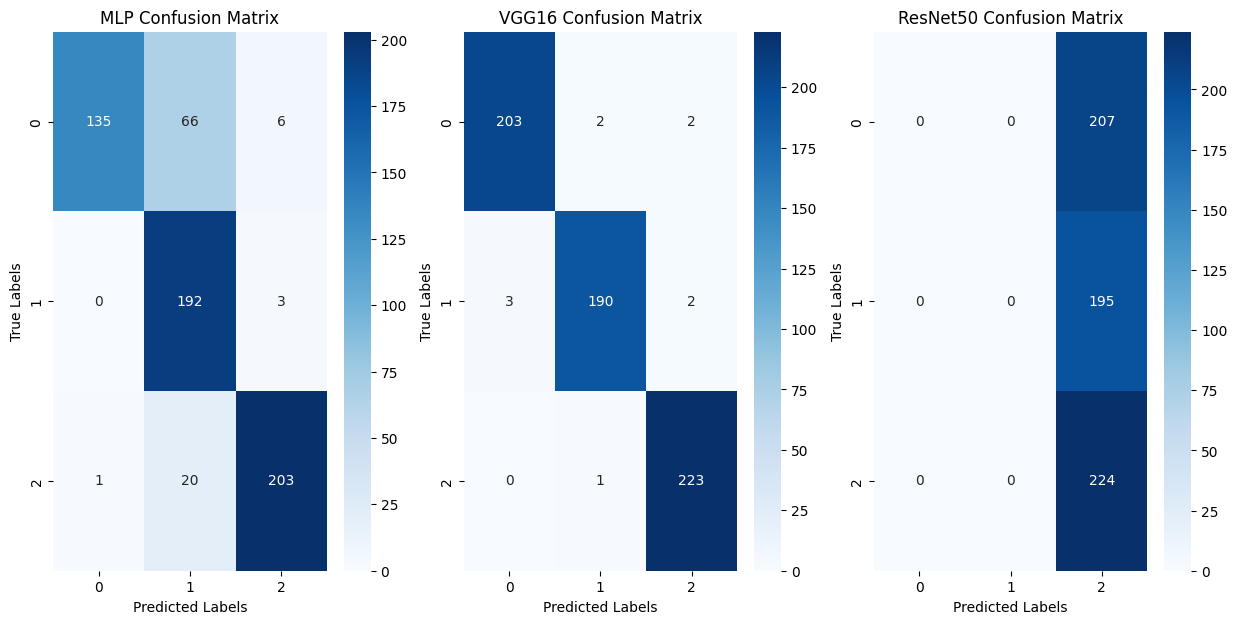

In [ ]:
# Cell 14: Display confusion matrices
conf_mat_mlp = confusion_matrix(y_test, y_pred_mlp)
conf_mat_vgg16 = confusion_matrix(y_test, y_pred_vgg16)
conf_mat_resnet50 = confusion_matrix(y_test, y_pred_resnet50)

plt.figure(figsize=(15, 7))
plt.subplot(1, 3, 1)
sns.heatmap(conf_mat_mlp, annot=True, fmt='d', cmap='Blues')
plt.title('MLP Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

plt.subplot(1, 3, 2)
sns.heatmap(conf_mat_vgg16, annot=True, fmt='d', cmap='Blues')
plt.title('VGG16 Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

plt.subplot(1, 3, 3)
sns.heatmap(conf_mat_resnet50, annot=True, fmt='d', cmap='Blues')
plt.title('ResNet50 Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

In [ ]:
# Cell 15: Display classification reports
print("MLP Classification Report")
print(classification_report(y_test, y_pred_mlp))

print("VGG16 Classification Report")
print(classification_report(y_test, y_pred_vgg16))

print("ResNet50 Classification Report")
print(classification_report(y_test, y_pred_resnet50))

MLP Classification Report
              precision    recall  f1-score   support

           0       0.99      0.65      0.79       207
           1       0.69      0.98      0.81       195
           2       0.96      0.91      0.93       224

    accuracy                           0.85       626
   macro avg       0.88      0.85      0.84       626
weighted avg       0.89      0.85      0.85       626

VGG16 Classification Report
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       207
           1       0.98      0.97      0.98       195
           2       0.98      1.00      0.99       224

    accuracy                           0.98       626
   macro avg       0.98      0.98      0.98       626
weighted avg       0.98      0.98      0.98       626

ResNet50 Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       207
           1       0.00      0.00      0.00 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


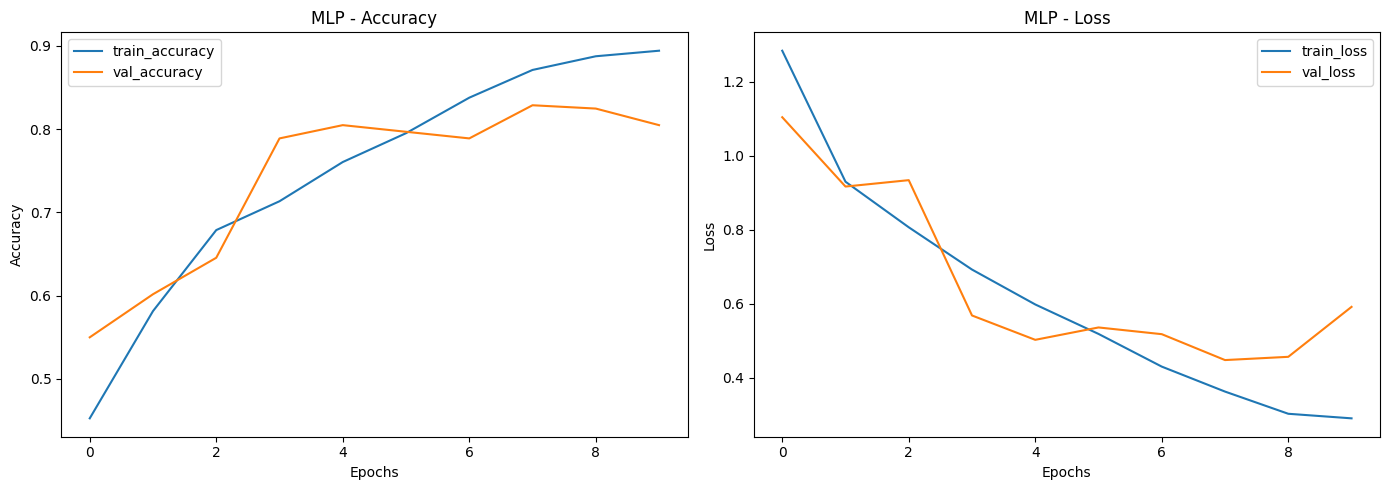

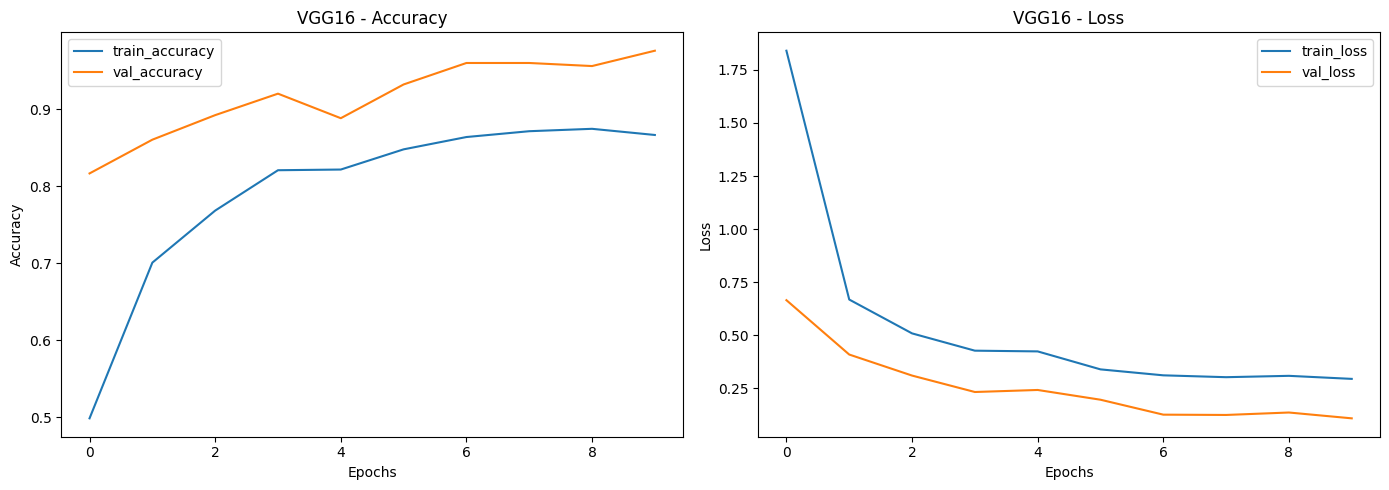

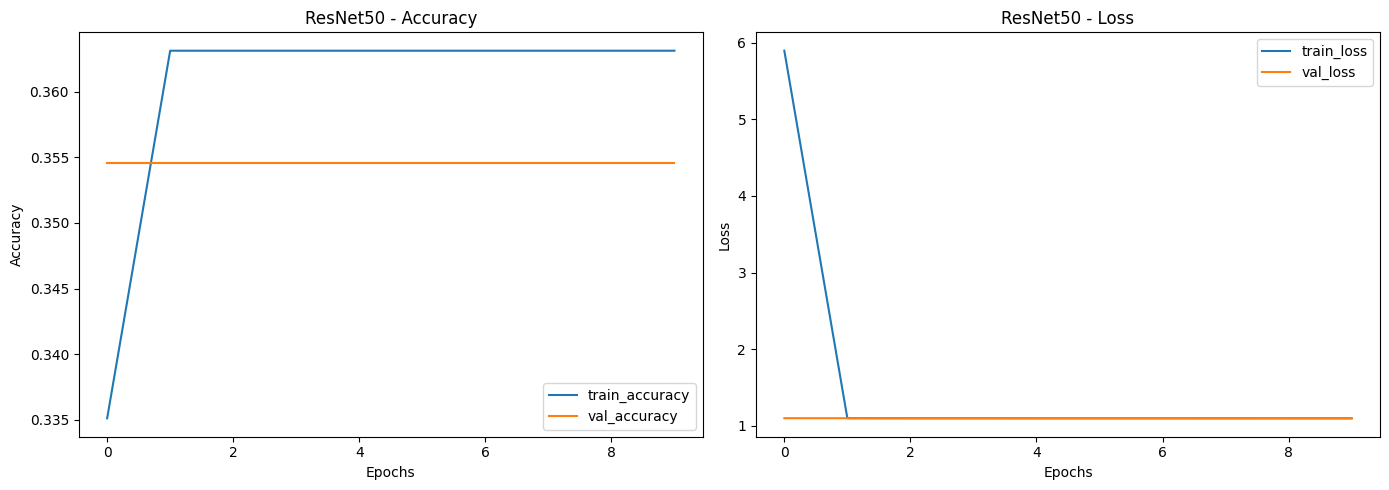

In [ ]:
# Cell 16: Plot accuracy and loss curves for each model
def plot_history(history, model_name):
    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train_accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP")
plot_history(history_vgg16, "VGG16")
plot_history(history_resnet50, "ResNet50")

In [ ]:
model_path = '/content/drive/MyDrive/Colab_Notebooks/final_model.keras'

# Save the VGG16 model
try:
    vgg16_model.save(model_path)
    print(f"VGG16 model saved successfully at: {model_path}")
except Exception as e:
    print(f"Error while saving the VGG16 model: {e}")

VGG16 model saved successfully at: /content/drive/MyDrive/Colab_Notebooks/final_model.keras


### Making Predictions with the Trained Model

Now that the models are trained and evaluated, you can use the best-performing model (VGG16 in this case) to make predictions on new, unseen images. Below is an example of how to load a sample image, preprocess it, and get a prediction.

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


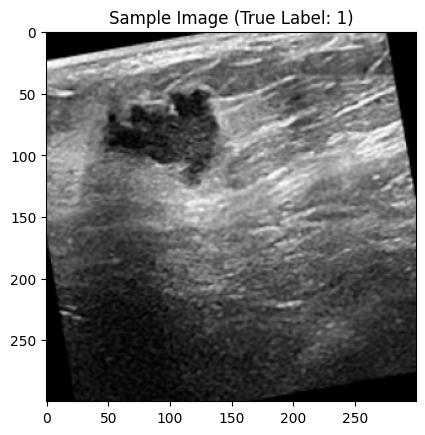

Raw prediction probabilities: [[0.03444209 0.9645422  0.00101575]]
Predicted class: 1
Predicted class name: malignant
True class name: malignant


In [ ]:
# Cell 17: Example of making a prediction on a new image

# Choose a sample image for prediction (replace with your actual image path)
# For demonstration, let's pick one from the test set for which we know the ground truth.
# In a real scenario, you would load a completely new image.

# Le  t's take the first image from the test set as an example
sample_image = X_test[0]
sample_true_label = y_test[0]

# Preprocess the sample image for VGG16 model
# VGG16 expects a 3-channel input and a batch dimension
# Our images are grayscale, so we need to convert them to 3 channels.
# Also, add an extra dimension for the batch size.

# Convert grayscale (1 channel) to 3 channels by stacking
sample_image_rgb = np.stack([sample_image, sample_image, sample_image], axis=-1)

# Add batch dimension (1, img_sz, img_sz, 3)
processed_image = np.expand_dims(sample_image_rgb, axis=0)

# Make prediction using the VGG16 model
vgg16_prediction = vgg16_model.predict(processed_image)

# Get the predicted class (index with highest probability)
predicted_class = np.argmax(vgg16_prediction, axis=1)[0]

# Display the image and results
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Image (True Label: {sample_true_label})")
plt.show()

print(f"Raw prediction probabilities: {vgg16_prediction}")
print(f"Predicted class: {predicted_class}")

# Map class number to actual class name
class_names = ['benign', 'malignant', 'normal']
print(f"Predicted class name: {class_names[predicted_class]}")
print(f"True class name: {class_names[sample_true_label]}")

### Loading the Saved Model

If you restart your Colab session or want to use the saved model in a different notebook or application, you would load it using `keras.models.load_model`:

In [ ]:
# Cell 18: Load the saved VGG16 model

from tensorflow import keras

# Define the path to your saved model
model_path = '/content/drive/MyDrive/Colab_Notebooks/final_model.keras'

try:
    # Load the model
    loaded_vgg16_model = keras.models.load_model(model_path)
    print(f"VGG16 model loaded successfully from: {model_path}")

    # You can now use loaded_vgg16_model for predictions
    # For example, to verify it's working:
    # loaded_prediction = loaded_vgg16_model.predict(processed_image)
    # print(f"Prediction from loaded model: {np.argmax(loaded_prediction, axis=1)[0]}")

except Exception as e:
    print(f"Error while loading the VGG16 model: {e}")

VGG16 model loaded successfully from: /content/drive/MyDrive/Colab_Notebooks/final_model.keras


### Fixing the Input Shape Mismatch

To resolve this, we need to ensure the image passed to the `loaded_vgg16_model` has a single channel before its internal `Conv2D` layer expands it to 3 channels. We will remove the `np.stack` step in the prediction code.

Attempting to load image from: /content/drive/MyDrive/Colab_Notebooks/malignant (17).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


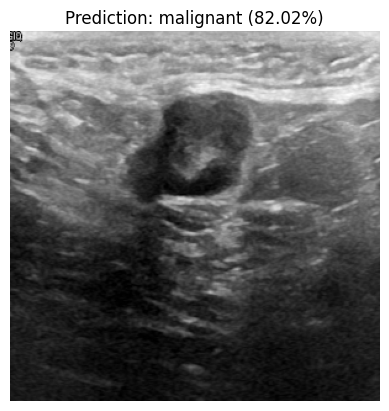


Class Probabilities:
  benign       → 14.09%
  malignant    → 82.02%
  normal       → 3.89%


In [ ]:
# Cell 21: Corrected Prediction code

# Ensure 'img_sz' (from Cell 4: 300) and 'class_names' (from Cell 17) are defined
# model_path (from Cell 18) and loaded_vgg16_model (from Cell 18) are also required.

# Define class names (ensure this is available for prediction)
class_names = ['benign', 'malignant', 'normal']

# 1. Define the image path
sample_img_path = '/content/drive/MyDrive/Colab_Notebooks/malignant (17).png' # <--- REPLACE THIS WITH YOUR IMAGE PATH

print(f"Attempting to load image from: {sample_img_path}")

# 2. Load the image using OpenCV
img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Image not found or could not be loaded from {sample_img_path}")
else:
    # 3. Resize the image
    img_resized = cv2.resize(img, (img_sz, img_sz))

    # 4. Normalize and reshape for VGG16 input
    # Only normalize and add batch/channel dimensions, do NOT stack to 3 channels here.
    # The model's first Conv2D layer will handle the grayscale to RGB conversion.
    img_input = (img_resized / 255.0) # Normalize to [0, 1]
    img_input = np.expand_dims(img_input, axis=-1) # Add channel dimension (300, 300) -> (300, 300, 1)
    img_input = np.expand_dims(img_input, axis=0)  # Add batch dimension (1, 300, 300, 1)

    # 5. Make prediction using the loaded VGG16 model
    prediction_probabilities = loaded_vgg16_model.predict(img_input)

    # 6. Get the predicted class and confidence
    predicted_class_index = np.argmax(prediction_probabilities, axis=1)[0]
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(prediction_probabilities) * 100

    # 7. Display the image and results
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    # 8. Print individual class probabilities
    print("\nClass Probabilities:")
    for i, prob in enumerate(prediction_probabilities[0]):
        print(f"  {class_names[i]:12s} → {prob*100:.2f}%")

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/Colab_Notebooks/final_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Cell 2 - Load saved model
import tensorflow as tf

vgg16_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/Colab_Notebooks/final_model.keras'
)
print("Loaded!")

Loaded!


In [ ]:
# Cell 3 - Save weights only
vgg16_model.save_weights('/content/drive/MyDrive/Colab_Notebooks/final_vgg16_weights.weights.h5')
print("Weights saved!")

Weights saved!


In [ ]:
# Cell 4 - Download
from google.colab import files
files.download('/content/drive/MyDrive/Colab_Notebooks/final_vgg16_weights.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import keras
print("TF:", tf.__version__)
print("Keras:", keras.__version__)

TF: 2.20.0
Keras: 3.13.2
